# Vietnam Financial News–Market EDA
Notebook tổng hợp chạy tuần tự News Silver, Market Silver và Event–Market Gold. Mỗi cell chỉ hiển thị tối đa một bảng.

## News Silver EDA
EDA riêng cho chất lượng, nội dung, nguồn và ticker của Silver News.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
news = pd.read_parquet(ROOT / 'data_lake/silver/news')
news['published_timestamp'] = pd.to_datetime(news['published_timestamp'], utc=True)
news['published_month'] = news['published_timestamp'].dt.tz_convert('Asia/Ho_Chi_Minh').dt.to_period('M').astype(str)
print(f'News rows: {len(news):,}')

News rows: 2,879


/tmp/ipykernel_912164/3659161383.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news['published_month'] = news['published_timestamp'].dt.tz_convert('Asia/Ho_Chi_Minh').dt.to_period('M').astype(str)


In [2]:
quality = pd.Series({
    'rows': len(news),
    'distinct_event_id': news.event_id.nunique(),
    'duplicate_url': news.url.dropna().duplicated().sum(),
    'duplicate_content_hash': news.content_hash.dropna().duplicated().sum(),
    'invalid_rows': (~news.is_valid).sum(),
    'missing_title': news.title.fillna('').str.strip().eq('').sum(),
    'full_article': news.has_full_text.sum(),
    'metadata_only': (~news.has_full_text).sum(),
    'with_vn30_ticker': news.merged_tickers.map(len).gt(0).sum(),
}, name='value').to_frame()
display(quality)

,value
rows,2879
distinct_event_id,2879
duplicate_url,0
duplicate_content_hash,1
invalid_rows,0
missing_title,0
full_article,2707
metadata_only,172
with_vn30_ticker,2879


In [3]:
date_range = news[['published_timestamp']].agg(['min','max'])
display(date_range)

,published_timestamp
min,2020-01-01 08:00:00+00:00
max,2026-10-06 10:07:00+00:00


,articles,rate_pct
has_full_text,,
Full article,2707,94.03
Metadata only,172,5.97


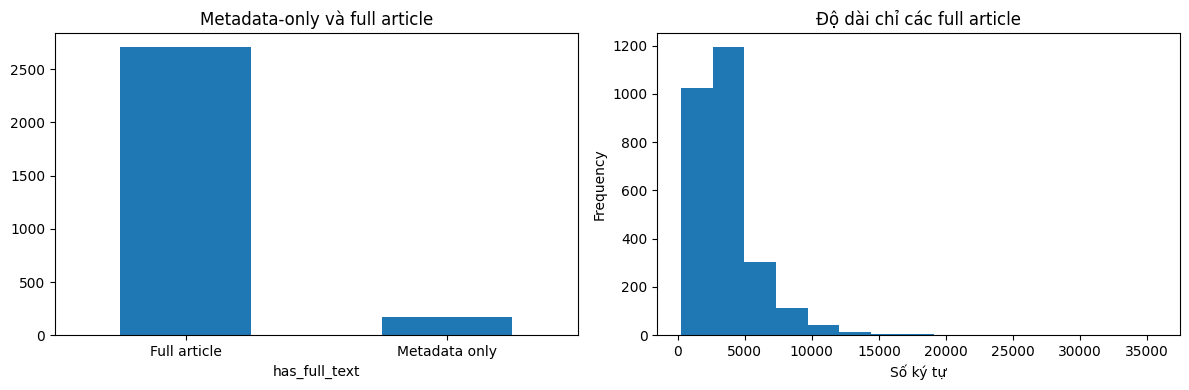

In [4]:
content_status = news.has_full_text.map({True: 'Full article', False: 'Metadata only'}).value_counts()
full_lengths = news.loc[news.has_full_text, 'content_length']
display(pd.DataFrame({
    'articles': content_status,
    'rate_pct': (100 * content_status / len(news)).round(2),
}))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
content_status.plot.bar(ax=axes[0], title='Metadata-only và full article', rot=0)
full_lengths.plot.hist(bins=15, ax=axes[1], title='Độ dài chỉ các full article')
axes[1].set_xlabel('Số ký tự')
plt.tight_layout(); plt.show()

In [5]:
full_length_summary = full_lengths.describe().to_frame('full_article_length')
display(full_length_summary)

,full_article_length
count,2707.000000
mean,3632.920207
std,2338.011982
min,241.000000
25%,2109.000000
50%,3093.000000
75%,4431.500000
max,35666.000000


,articles,full_articles,full_text_rate_pct
source,,,
cafef,472,464,98.31
chungta,319,299,93.73
fpt shop,144,144,100.00
báo dân trí,122,121,99.18
báo thanh niên,92,92,100.00
kenh14.vn,91,89,97.80
baonghean.vn,87,87,100.00
báo tuổi trẻ,87,87,100.00
vnexpress,77,77,100.00


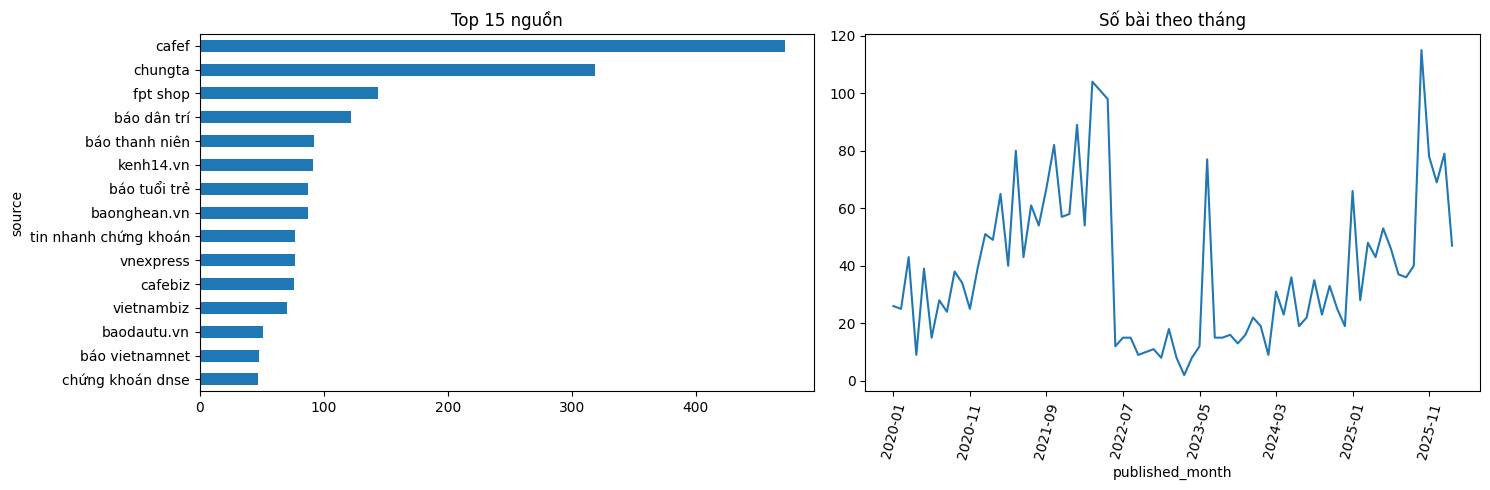

In [6]:
source_stats = news.groupby('source').agg(
    articles=('event_id','size'),
    full_articles=('has_full_text','sum'),
).sort_values('articles', ascending=False)
source_stats['full_text_rate_pct'] = (100 * source_stats.full_articles / source_stats.articles).round(2)
display(source_stats.head(20))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
source_stats.head(15).sort_values('articles').articles.plot.barh(ax=axes[0], title='Top 15 nguồn')
news.groupby('published_month').size().plot(ax=axes[1], title='Số bài theo tháng')
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout(); plt.show()

In [7]:
ticker_counts = news.explode('merged_tickers').merged_tickers.value_counts()
ticker_pairs = [(list(r), list(n)) for r,n in zip(news.rulebased_tickers, news.ner_tickers)]
agreement = pd.Series({
    'rule_ner_agree': sum(set(r) == set(n) and len(r) > 0 for r,n in ticker_pairs),
    'rule_only': sum(len(r) > 0 and len(n) == 0 for r,n in ticker_pairs),
    'ner_only': sum(len(n) > 0 and len(r) == 0 for r,n in ticker_pairs),
    'partial_disagreement': sum(len(r) > 0 and len(n) > 0 and set(r) != set(n) for r,n in ticker_pairs),
})
display(agreement.to_frame('articles'))

,articles
rule_ner_agree,1980
rule_only,673
ner_only,10
partial_disagreement,216


,mentions
merged_tickers,
FPT,1316
ACB,1075
CTG,334
VCB,298
TCB,189
BID,178
VPB,159
STB,129
BCM,128


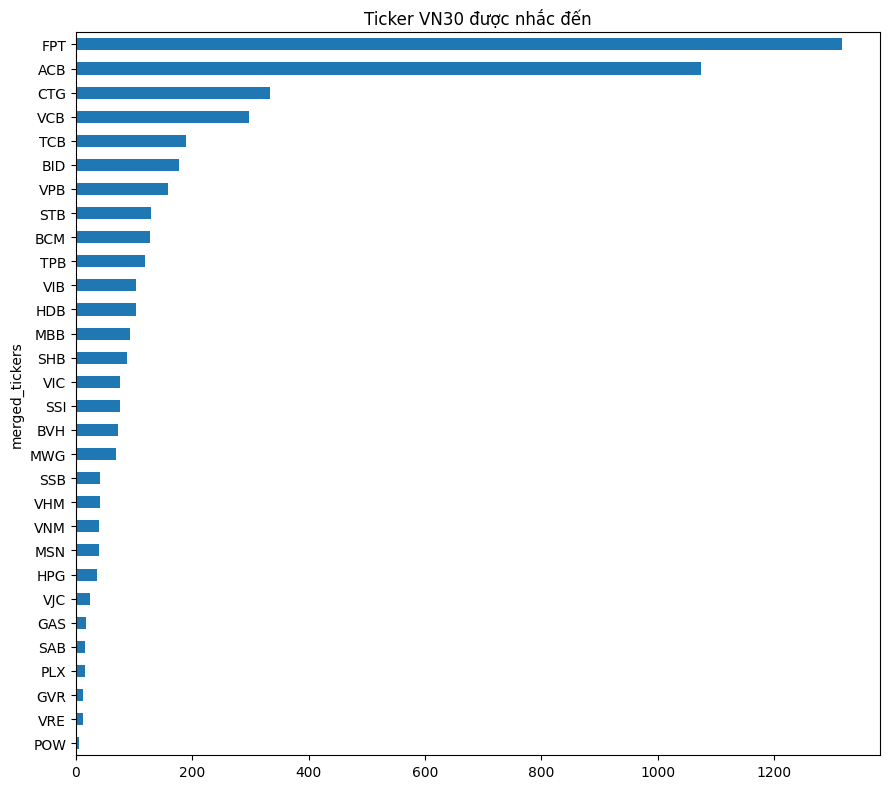

In [8]:
display(ticker_counts.to_frame('mentions'))
ticker_counts.sort_values().plot.barh(figsize=(9,8), title='Ticker VN30 được nhắc đến')
plt.tight_layout(); plt.show()

## Market Silver EDA
EDA riêng cho coverage, chất lượng OHLCV, return và volatility của VN30.

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
market = pd.read_parquet(ROOT / 'data_lake/silver/market_daily')
market['session_date'] = pd.to_datetime(market.session_date.astype(str))
print(f'Market rows: {len(market):,}')

Market rows: 52,142


In [10]:
quality = pd.Series({
    'rows': len(market),
    'tickers': market.ticker.nunique(),
    'sessions': market.session_date.nunique(),
    'first_session': market.session_date.min(),
    'last_session': market.session_date.max(),
    'duplicate_keys': market.duplicated(['ticker','session_date','interval','source']).sum(),
    'invalid_rows': (~market.is_valid).sum(),
    'weekend_rows': market.session_date.dt.dayofweek.ge(5).sum(),
    'missing_daily_return': market.daily_return.isna().sum(),
    'abs_return_gt_10pct': market.daily_return.abs().gt(.10).sum(),
}, name='value').to_frame()
display(quality)

,value
rows,52142
tickers,30
sessions,1788
first_session,2019-12-02 00:00:00
last_session,2026-10-07 00:00:00
duplicate_keys,0
invalid_rows,0
weekend_rows,0
missing_daily_return,30
abs_return_gt_10pct,46


,sessions,first_session,last_session,missing_return
ticker,,,,
BCM,1443,2021-03-15,2026-10-07,1
SSB,1445,2021-03-24,2026-10-07,1
ACB,1519,2020-12-09,2026-10-07,1
VIB,1542,2020-11-10,2026-10-07,1
GVR,1703,2020-03-17,2026-10-07,1
VNM,1774,2019-12-02,2026-10-07,1
VCB,1774,2019-12-02,2026-10-07,1
TCB,1774,2019-12-02,2026-10-07,1
STB,1774,2019-12-02,2026-10-07,1


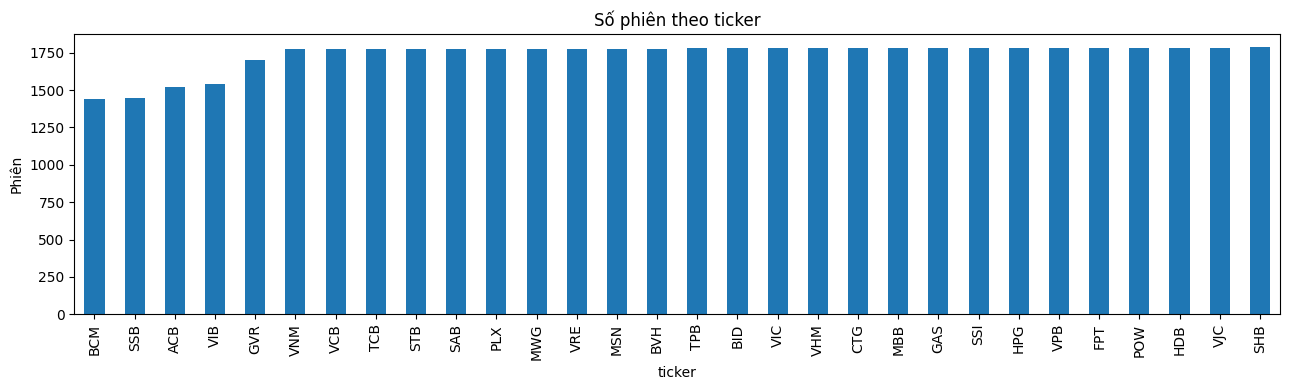

In [11]:
coverage = market.groupby('ticker').agg(
    sessions=('session_date','nunique'),
    first_session=('session_date','min'),
    last_session=('session_date','max'),
    missing_return=('daily_return', lambda s: s.isna().sum()),
).sort_values('sessions')
display(coverage)
coverage.sessions.plot.bar(figsize=(13,4), title='Số phiên theo ticker')
plt.ylabel('Phiên'); plt.tight_layout(); plt.show()

In [12]:
returns = market.daily_return.dropna()
return_summary = returns.describe(percentiles=[.01,.05,.5,.95,.99]).to_frame('value')
return_summary['unit'] = '%'
return_summary.loc['count', 'unit'] = 'rows'
return_summary.loc[return_summary.index != 'count', 'value'] *= 100
display(return_summary.rename(columns={'value':'daily_return'}))

,daily_return,unit
count,52112.000000,rows
mean,0.064297,%
std,2.157295,%
min,-49.539880,%
1%,-6.868627,%
5%,-3.234342,%
50%,0.000000,%
95%,3.664246,%
99%,6.874999,%
max,31.250000,%


,mean_return,volatility,median_volume
ticker,,,
GVR,0.113302,2.835023,2368900.0
SHB,0.128701,2.646165,24847933.0
SSI,0.111392,2.590218,22104715.0
VRE,0.011075,2.470883,4130100.0
STB,0.135536,2.401022,10710290.0
TCB,0.055398,2.385573,6877050.0
VHM,0.068154,2.302428,7714800.0
VIC,0.110127,2.279276,3602500.0
POW,0.035903,2.259786,7812945.0


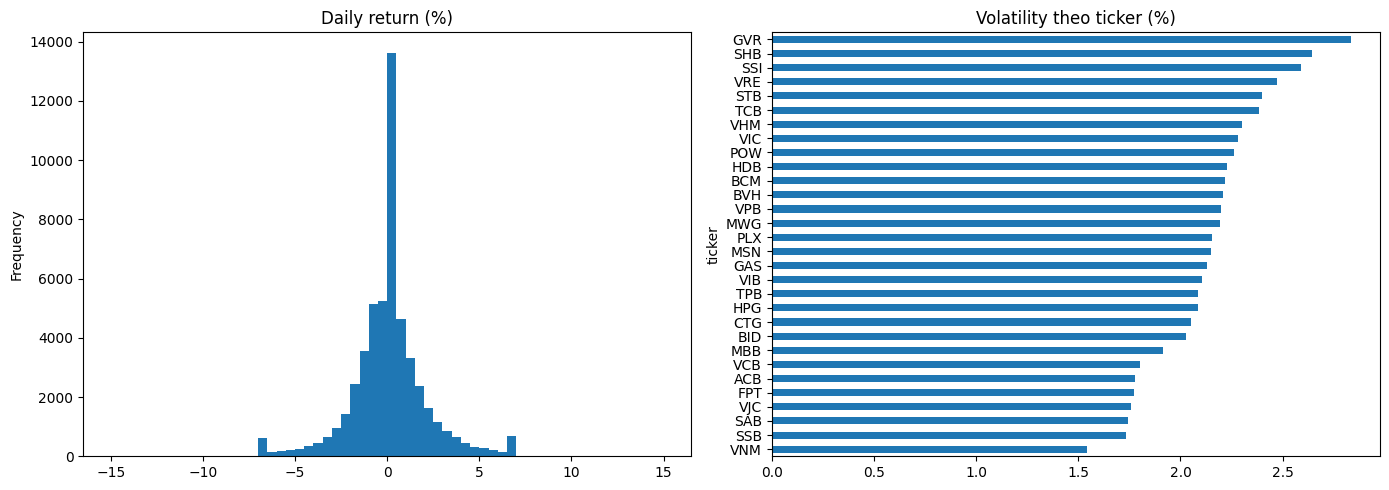

In [13]:
ticker_risk = market.groupby('ticker').agg(
    mean_return=('daily_return','mean'),
    volatility=('daily_return','std'),
    median_volume=('volume','median'),
).sort_values('volatility', ascending=False)
display(ticker_risk.assign(mean_return=lambda x:100*x.mean_return, volatility=lambda x:100*x.volatility))
fig, axes = plt.subplots(1,2,figsize=(14,5))
(100*returns).clip(-15,15).plot.hist(bins=60, ax=axes[0], title='Daily return (%)')
(100*ticker_risk.volatility).sort_values().plot.barh(ax=axes[1], title='Volatility theo ticker (%)')
plt.tight_layout(); plt.show()

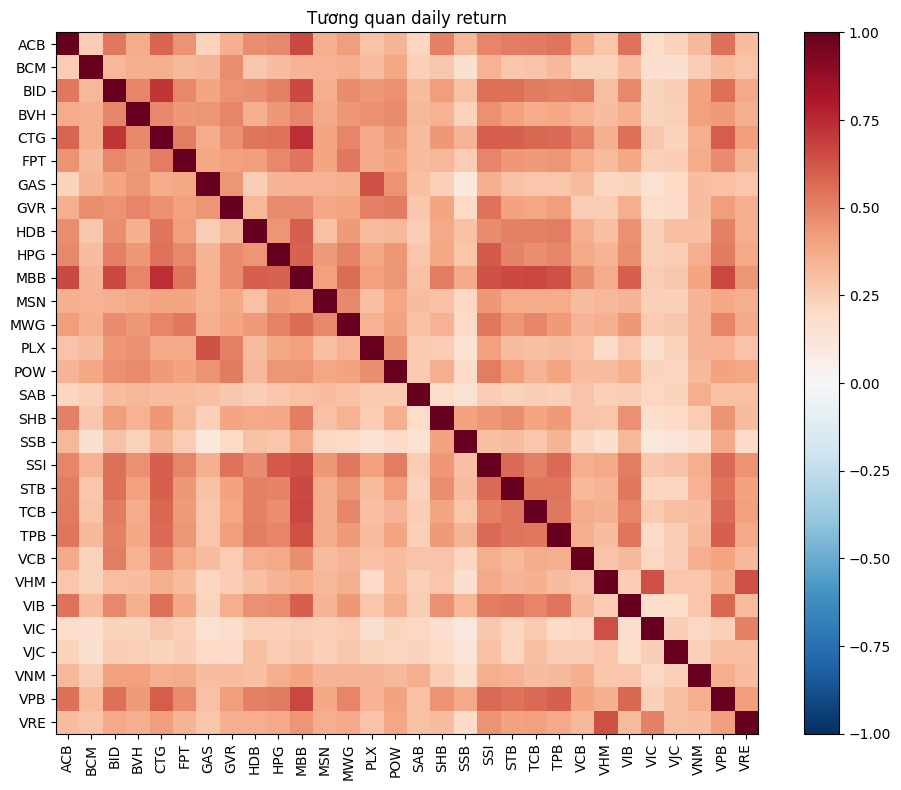

In [14]:
return_matrix = market.pivot(index='session_date', columns='ticker', values='daily_return')
corr = return_matrix.corr(min_periods=100)
fig, ax = plt.subplots(figsize=(10,8))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.index)
ax.set_title('Tương quan daily return')
fig.colorbar(image, ax=ax); plt.tight_layout(); plt.show()

## Event–Market Gold EDA
EDA riêng cho point-in-time join, event-window coverage và abnormal return.

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
gold = pd.read_parquet(ROOT / 'data_lake/gold/news_market_impact')
for c in ['event_date_vn','t0_date','anchor_date_t_minus_1','session_date']:
    gold[c] = pd.to_datetime(gold[c], errors='coerce')
print(f'Gold rows: {len(gold):,}')

Gold rows: 44,199


In [16]:
pairs = gold.drop_duplicates(['event_id','ticker']).copy()
bad_t0 = np.where(pairs.published_after_close, pairs.t0_date <= pairs.event_date_vn, pairs.t0_date < pairs.event_date_vn)
quality = pd.Series({
    'rows': len(gold),
    'event_ticker_pairs': len(pairs),
    'events': gold.event_id.nunique(),
    'tickers': gold.ticker.nunique(),
    'duplicate_window_keys': gold.duplicated(['event_id','ticker','relative_session']).sum(),
    'published_after_close': pairs.published_after_close.sum(),
    'bad_t0': bad_t0.sum(),
    'bad_anchor': (pairs.anchor_date_t_minus_1 >= pairs.t0_date).sum(),
}, name='value').to_frame()
display(quality)

,value
rows,44199
event_ticker_pairs,4911
events,2879
tickers,30
duplicate_window_keys,0
published_after_close,1728
bad_t0,0
bad_anchor,0


,requested,available,availability_pct
relative_session,,,
-5,4911,4886,99.49
-3,4911,4887,99.51
-2,4911,4887,99.51
-1,4911,4887,99.51
0,4911,4911,100.00
1,4911,4887,99.51
2,4911,4860,98.96
3,4911,4832,98.39
5,4911,4830,98.35


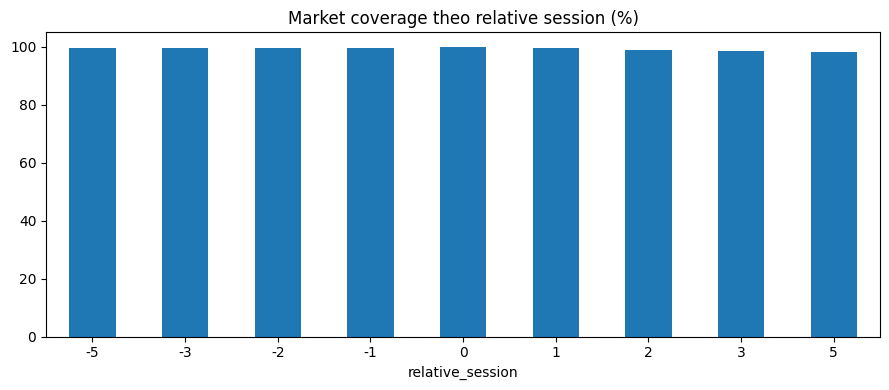

In [17]:
coverage = gold.groupby('relative_session').agg(
    requested=('event_id','size'),
    available=('has_market_data','sum'),
)
coverage['availability_pct'] = (100*coverage.available/coverage.requested).round(2)
display(coverage)
coverage.availability_pct.plot.bar(figsize=(9,4), ylim=(0,105), title='Market coverage theo relative session (%)', rot=0)
plt.tight_layout(); plt.show()

,count,mean,median,std,se,ci95_low,ci95_high
relative_session,,,,,,,
-5,4886,-0.081,0.173,2.845,0.041,-0.161,-0.001
-3,4887,-0.094,0.063,2.076,0.030,-0.152,-0.036
-2,4887,-0.078,0.043,1.515,0.022,-0.120,-0.035
-1,4887,0.000,0.000,0.000,0.000,0.000,0.000
0,4887,0.020,-0.064,1.640,0.023,-0.026,0.066
1,4863,0.069,-0.104,2.355,0.034,0.003,0.135
2,4836,0.080,-0.180,2.710,0.039,0.004,0.156
3,4808,0.063,-0.146,2.990,0.043,-0.021,0.148
5,4806,0.079,-0.287,3.554,0.051,-0.021,0.180


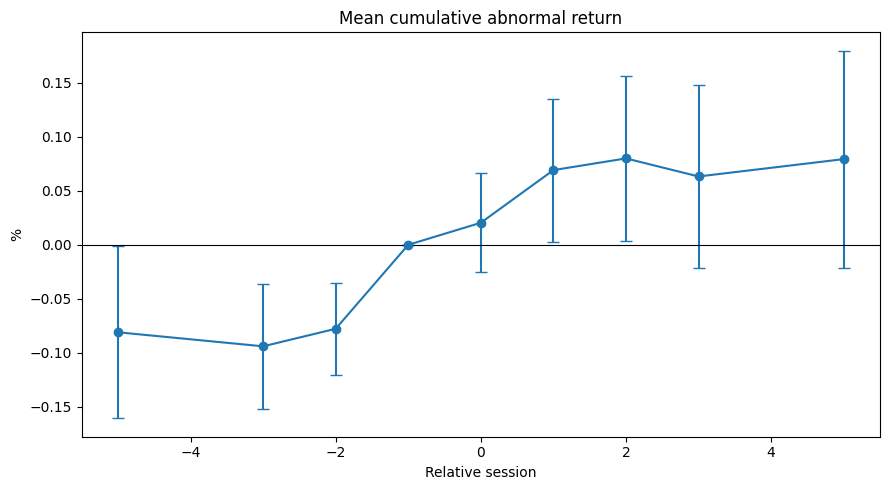

In [18]:
available = gold[gold.has_market_data & gold.abnormal_return.notna()].copy()
stats = available.groupby('relative_session').abnormal_return.agg(['count','mean','median','std'])
stats['se'] = stats['std']/np.sqrt(stats['count'])
stats['ci95_low'] = stats['mean'] - 1.96*stats['se']
stats['ci95_high'] = stats['mean'] + 1.96*stats['se']
display((100*stats).assign(count=stats['count']).round(3))
fig, ax = plt.subplots(figsize=(9,5))
x = stats.index.to_numpy()
mean = (100*stats['mean']).to_numpy()
error = (100*1.96*stats['se']).to_numpy()
ax.errorbar(x, mean, yerr=error, marker='o', capsize=4)
ax.axhline(0,color='black',linewidth=.8)
ax.set(title='Mean cumulative abnormal return', xlabel='Relative session', ylabel='%')
plt.tight_layout(); plt.show()

In [19]:
focus = available[available.relative_session.isin([0,1,3,5])]
timing = focus.groupby(['published_after_close','relative_session']).agg(
    events=('event_id','size'), mean_abnormal=('abnormal_return','mean'),
).reset_index()
timing['mean_abnormal_pct'] = (100*timing.mean_abnormal).round(3)
display(timing)

,published_after_close,relative_session,events,mean_abnormal,mean_abnormal_pct
0,False,0,3168,0.000086,0.009
1,False,1,3168,0.000860,0.086
2,False,3,3148,0.000464,0.046
3,False,5,3146,0.000790,0.079
4,True,0,1719,0.000423,0.042
5,True,1,1695,0.000379,0.038
6,True,3,1660,0.000956,0.096
7,True,5,1660,0.000801,0.080


In [20]:
ticker_t5 = available[available.relative_session.eq(5)].groupby('ticker').agg(
    events=('event_id','size'), mean_abnormal=('abnormal_return','mean'),
).query('events >= 20').sort_values('mean_abnormal')
ticker_t5['mean_abnormal_pct'] = (100*ticker_t5.mean_abnormal).round(3)
display(ticker_t5[['events','mean_abnormal_pct']])
print('Cảnh báo: các thống kê này mô tả tương quan, không chứng minh tác động nhân quả.')

,events,mean_abnormal_pct
ticker,,
SSB,41,-3.010
MWG,68,-1.128
SHB,87,-0.557
VJC,20,-0.553
VCB,293,-0.431
VNM,39,-0.418
VHM,41,-0.354
HPG,31,-0.299
BID,174,-0.181


Cảnh báo: các thống kê này mô tả tương quan, không chứng minh tác động nhân quả.
